# Notebook 01 — Exploratory Data Analysis

**Repository:** `kubernetes/kubernetes`  
**Member:** Muhammad Asrofi Syaikho — Data Engineer 

---

Notebook ini berfokus pada pembersihan data mentah hasil *scraping* GitHub API dan menyajikan visualisasi tren volume issue serta status penyelesaian Pull Request. Output dari notebook ini akan menghasilkan berkas data bersih di folder `data/clean/` untuk digunakan pada tahapan analisis selanjutnya.

---
### AI Disclosure

**Member:** Muhammad Asrofi Syaikho — Data Engineer | **Tools used:** Claude

| Tugas | Alat | Prompt (Ringkasan) | Pemanfaatan Output |
|------|------|-------------------|---------------------|
| Penyesuaian struktur code EDA | Claude | "Generate saya code EDA mengikuti objektif yang telah diberikan" | Digunakan sebagai kerangka kode dan pemrosesan data. |

**Written entirely without AI:** Sel Interpretasi

---
## 0. Setup Lingkungan Pengembangan

In [7]:
import os
import glob
import warnings
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

RAW_DIR   = os.path.join("..", "data", "raw")
CLEAN_DIR = os.path.join("..", "data", "clean")
REPORT_DIR = os.path.join("..", "report")

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

---
## 1. Preprocessing & Rekayasa Fitur Dataset Issues

Memuat berkas CSV terbaru hasil ekstraksi dari GitHub API untuk dataset issues.

In [2]:
# Load data mentah issues
df_issues_raw = pd.read_csv(os.path.join(RAW_DIR, "dataset_issues_raw.csv"))
print(f"Total baris issue mentah: {len(df_issues_raw):,}")

# 1. Parsing Label untuk mendeteksi bug (label spesifik K8s: 'kind/bug')
# Karena kolom 'labels' bertipe string representation dari list, kita gunakan str.contains
df_issues_raw['is_bug'] = df_issues_raw['labels'].astype(str).str.contains('kind/bug', case=False, na=False)

# 2. Konversi kolom penanggalan ke datetime secara aman
df_issues_raw['created_at'] = pd.to_datetime(df_issues_raw['created_at'], errors='coerce')
df_issues_raw['closed_at'] = pd.to_datetime(df_issues_raw['closed_at'], errors='coerce')

# 3. Hitung Waktu Penyelesaian (Time-to-close) dalam satuan hari
# Metrik ini hanya valid jika issue sudah selesai/closed (closed_at tidak null)
df_issues_raw['time_to_close_days'] = (df_issues_raw['closed_at'] - df_issues_raw['created_at']).dt.total_seconds() / (24 * 3600)

# 4. Seleksi kolom penting untuk meminimalkan beban memori kerja kelompok
issues_clean_cols = ['id', 'number', 'state', 'created_at', 'closed_at', 'is_bug', 'time_to_close_days']
df_issues_clean = df_issues_raw[issues_clean_cols].copy()

# Simpan dataset issues bersih
issues_clean_path = os.path.join(CLEAN_DIR, "dataset_issues_clean.csv")
df_issues_clean.to_csv(issues_clean_path, index=False)
print(f"✔ Berhasil mengekspor data bersih issues ke: {issues_clean_path} ({len(df_issues_clean):,} baris)")

Total baris issue mentah: 1,213
✔ Berhasil mengekspor data bersih issues ke: ..\data\clean\dataset_issues_clean.csv (1,213 baris)


---
## 2. Preprocessing & Rekayasa Fitur Dataset Pull Requests

Memuat berkas CSV terbaru hasil ekstraksi dari GitHub API untuk dataset issues.

In [5]:
# Load data mentah PRs
df_prs_raw = pd.read_csv(os.path.join(RAW_DIR, "dataset_prs_raw.csv"))
print(f"Total baris PR mentah: {len(df_prs_raw):,}")

# 1. Konversi penanggalan ke datetime
df_prs_raw['created_at'] = pd.to_datetime(df_prs_raw['created_at'], errors='coerce')
df_prs_raw['closed_at'] = pd.to_datetime(df_prs_raw['closed_at'], errors='coerce')
df_prs_raw['merged_at'] = pd.to_datetime(df_prs_raw['merged_at'], errors='coerce')

# 2. Ekstrak objek tanggal murni (tanpa jam) untuk menghitung frekuensi harian (Kebutuhan Poisson)
df_prs_raw['created_date'] = df_prs_raw['created_at'].dt.date

# 3. Hitung durasi PR sampai berhasil di-merge (Kebutuhan Simulasi Monte Carlo Member E)
# PENTING: Durasi hanya dihitung jika PR tersebut sukses di-merge (merged_at tidak kosong)
df_prs_raw['duration_to_merge_days'] = (df_prs_raw['merged_at'] - df_prs_raw['created_at']).dt.total_seconds() / (24 * 3600)

# Indicator boolean apakah sukses di-merge atau ditolak tanpa merge
df_prs_raw['is_merged'] = df_prs_raw['merged_at'].notna()

# 4. Seleksi kolom penting untuk diserahterimakan (handoff)
prs_clean_cols = ['id', 'number', 'state', 'created_at', 'closed_at', 'merged_at', 'created_date', 'is_merged', 'duration_to_merge_days']
df_prs_clean = df_prs_raw[prs_clean_cols].copy()

# Simpan dataset PR bersih
prs_clean_path = os.path.join(CLEAN_DIR, "dataset_prs_clean.csv")
df_prs_clean.to_csv(prs_clean_path, index=False)
print(f"✔ Berhasil mengekspor data bersih PR ke: {prs_clean_path} ({len(df_prs_clean):,} baris)")

Total baris PR mentah: 5,000
✔ Berhasil mengekspor data bersih PR ke: ..\data\clean\dataset_prs_clean.csv (5,000 baris)


---
## 3. Analisis Data Eksploratif (EDA)

### 3.1 Visualisasi Eksplorasi Data Awal
Bagian ini digunakan untuk memvalidasi bahwa bentuk sebaran data masuk akal sebelum diolah secara matematis oleh anggota tim lainnya.

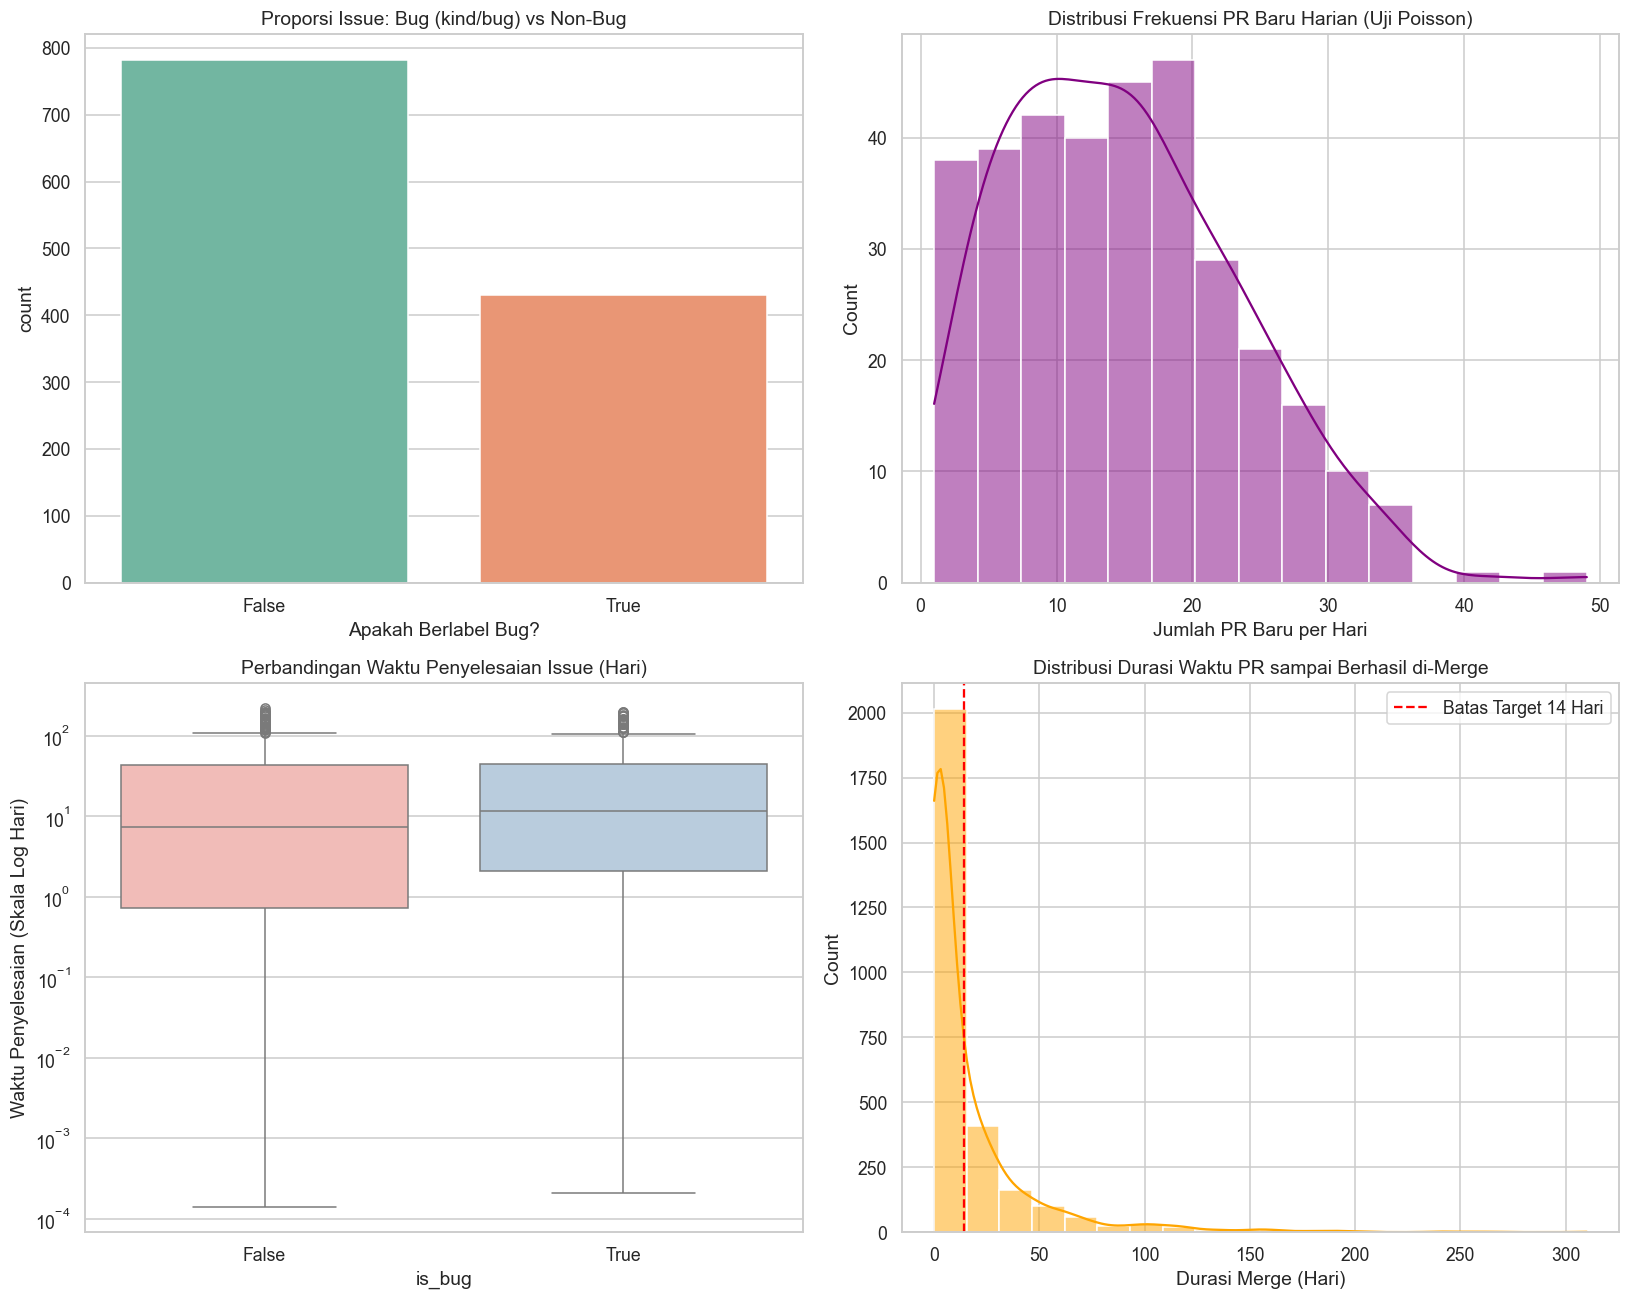

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Proporsi Bug vs Non-Bug (Kebutuhan Member B & C)
sns.countplot(data=df_issues_clean, x='is_bug', ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Proporsi Issue: Bug (kind/bug) vs Non-Bug")
axes[0, 0].set_xlabel("Apakah Berlabel Bug?")

# Subplot 2: Frekuensi PR Baru Harian (Kebutuhan Member B)
df_daily_pr = df_prs_clean.groupby('created_date').size().reset_index(name='pr_count')
sns.histplot(data=df_daily_pr, x='pr_count', kde=True, ax=axes[0, 1], color="purple", bins=15)
axes[0, 1].set_title("Distribusi Frekuensi PR Baru Harian (Uji Poisson)")
axes[0, 1].set_xlabel("Jumlah PR Baru per Hari")

# Subplot 3: Boxplot Time-to-close (Kebutuhan Member D)
# Menghapus data Na/Null sementara untuk keperluan plotting visual
df_issues_closed = df_issues_clean.dropna(subset=['time_to_close_days'])
sns.boxplot(data=df_issues_closed, x='is_bug', y='time_to_close_days', ax=axes[1, 0], palette="Pastel1")
axes[1, 0].set_title("Perbandingan Waktu Penyelesaian Issue (Hari)")
axes[1, 0].set_yscale('log') # Menggunakan skala logaritmik karena variansi ekstrim pada proyek open-source
axes[1, 0].set_ylabel("Waktu Penyelesaian (Skala Log Hari)")

# Subplot 4: Distribusi Durasi Waktu Merge PR (Kebutuhan Member E)
df_prs_merged = df_prs_clean.dropna(subset=['duration_to_merge_days'])
sns.histplot(data=df_prs_merged, x='duration_to_merge_days', kde=True, ax=axes[1, 1], color="orange", bins=20)
axes[1, 1].axvline(x=14, color='red', linestyle='--', label='Batas Target 14 Hari')
axes[1, 1].set_title("Distribusi Durasi Waktu PR sampai Berhasil di-Merge")
axes[1, 1].set_xlabel("Durasi Merge (Hari)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---
## 5. Ringkasan Hasil

**Berkas yang Dihasilkan:**
- `data/clean/dataset_issues_clean.csv` — Data objek issues bersih.
- `data/clean/dataset_prs_clean.csv` — Data objek pull requests bersih.

Notebook siap digunakan dan seluruh dataset terisolasi secara aman tanpa risiko error skema kolom.